In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import pandas as pd

trades = pd.read_csv("/content/drive/MyDrive/Primetrade_Assignment/historical_data.csv")
sentiment = pd.read_csv("/content/drive/MyDrive/Primetrade_Assignment/fear_greed_index.csv")

In [13]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [14]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")

# Drop unwanted columns
trades = trades.drop(columns=[
    'coin', 'size_tokens', 'direction',
    'transaction_hash', 'order_id', 'trade_id',
    'timestamp', 'crossed'
])

In [15]:
trades.head()

,account,execution_price,size_usd,side,timestamp_ist,start_position,closed_pnl,fee
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9769,7872.16,BUY,02-12-2024 22:50,0.000000,0.0,0.345404
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9800,127.68,BUY,02-12-2024 22:50,986.524596,0.0,0.005600
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9855,1150.63,BUY,02-12-2024 22:50,1002.518996,0.0,0.050431
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9874,1142.04,BUY,02-12-2024 22:50,1146.558564,0.0,0.050043
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9894,69.75,BUY,02-12-2024 22:50,1289.488521,0.0,0.003055


In [16]:
trades.columns

Index(['account', 'execution_price', 'size_usd', 'side', 'timestamp_ist',
       'start_position', 'closed_pnl', 'fee'],
      dtype='object')

In [17]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [18]:
# ---------------- CLEAN TRADES ----------------
trades.columns = trades.columns.str.lower().str.replace(" ", "_")

trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True)
trades['date'] = trades['timestamp_ist'].dt.date

# Rename columns for consistency
trades.rename(columns={
    'closed_pnl': 'pnl',
    'size_usd': 'size_usd'
}, inplace=True)

# ---------------- CLEAN SENTIMENT ----------------
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Keep only required columns
sentiment = sentiment[['date', 'classification', 'value']]


In [22]:
trades.head()

,account,execution_price,size_usd,side,start_position,pnl,fee,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9769,7872.16,BUY,0.000000,0.0,0.345404,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9800,127.68,BUY,986.524596,0.0,0.005600,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9855,1150.63,BUY,1002.518996,0.0,0.050431,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9874,1142.04,BUY,1146.558564,0.0,0.050043,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9894,69.75,BUY,1289.488521,0.0,0.003055,2024-12-02


In [20]:
trades = trades.drop(columns=['timestamp_ist'])

In [21]:
sentiment.head()

,date,classification,value
0,2018-02-01,Fear,30
1,2018-02-02,Extreme Fear,15
2,2018-02-03,Fear,40
3,2018-02-04,Extreme Fear,24
4,2018-02-05,Extreme Fear,11


In [23]:
df = trades.merge(sentiment, on='date', how='left')
df = df.dropna(subset=['classification'])

In [24]:
df.head(5)

,account,execution_price,size_usd,side,start_position,pnl,fee,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9769,7872.16,BUY,0.000000,0.0,0.345404,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9800,127.68,BUY,986.524596,0.0,0.005600,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9855,1150.63,BUY,1002.518996,0.0,0.050431,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9874,1142.04,BUY,1146.558564,0.0,0.050043,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9894,69.75,BUY,1289.488521,0.0,0.003055,2024-12-02,Extreme Greed,80.0


In [25]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 211218 entries, 0 to 211223
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   account          211218 non-null  object 
 1   execution_price  211218 non-null  float64
 2   size_usd         211218 non-null  float64
 3   side             211218 non-null  object 
 4   start_position   211218 non-null  float64
 5   pnl              211218 non-null  float64
 6   fee              211218 non-null  float64
 7   date             211218 non-null  object 
 8   classification   211218 non-null  object 
 9   value            211218 non-null  float64
dtypes: float64(6), object(4)
memory usage: 17.7+ MB


,execution_price,size_usd,start_position,pnl,fee,value
count,211218.000000,2.112180e+05,2.112180e+05,211218.000000,211218.000000,211218.000000
mean,11415.047529,5.639192e+03,-2.994671e+04,48.549304,1.163960,51.649656
std,29448.010305,3.657557e+04,6.738170e+05,917.989791,6.758948,21.012784
min,0.000005,0.000000e+00,-1.433463e+07,-117990.104100,-1.175712,10.000000
25%,4.858550,1.937900e+02,-3.760725e+02,0.000000,0.016121,33.000000
50%,18.280000,5.970200e+02,8.477051e+01,0.000000,0.089572,49.000000
75%,101.895000,2.058878e+03,9.337697e+03,5.790132,0.393774,72.000000
max,109004.000000,3.921431e+06,3.050948e+07,135329.090100,837.471593,94.000000


In [26]:
df.duplicated().sum()

np.int64(0)

In [28]:
df['net_pnl'] = df['pnl'] - df['fee']
# Trade size
df['position_size'] = df['size_usd']
df['roi'] = df['net_pnl'] / (df['position_size'] + 1e-6)
df['is_profit'] = (df['net_pnl'] > 0).astype(int)

In [29]:
sentiment_perf = df.groupby('classification').agg({
    'pnl': ['mean', 'sum'],
    'is_profit': 'mean',
    'roi': 'mean'
}).reset_index()

print(sentiment_perf)

  classification        pnl               is_profit       roi
                       mean           sum      mean      mean
0   Extreme Fear  34.537862  7.391102e+05  0.368458  0.004108
1  Extreme Greed  67.892861  2.715171e+06  0.467694  0.039762
2           Fear  54.290400  3.357155e+06  0.411517  0.014922
3          Greed  42.743559  2.150129e+06  0.391249  0.019390
4        Neutral  34.307718  1.292921e+06  0.395903  0.009511


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

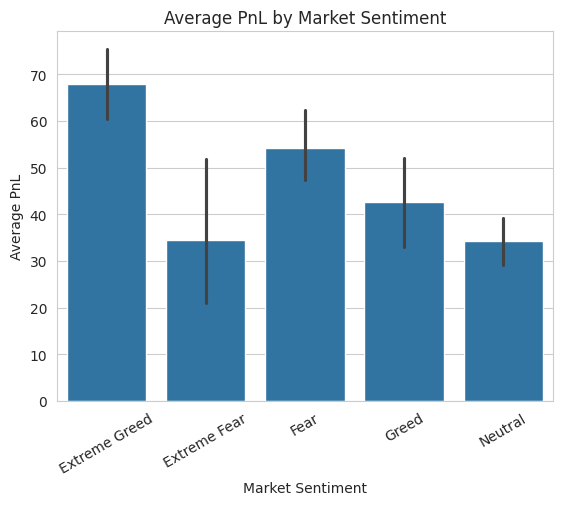

In [31]:
plt.figure()
sns.barplot(x='classification', y='pnl', data=df)
plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")
plt.xticks(rotation=30)
plt.show()

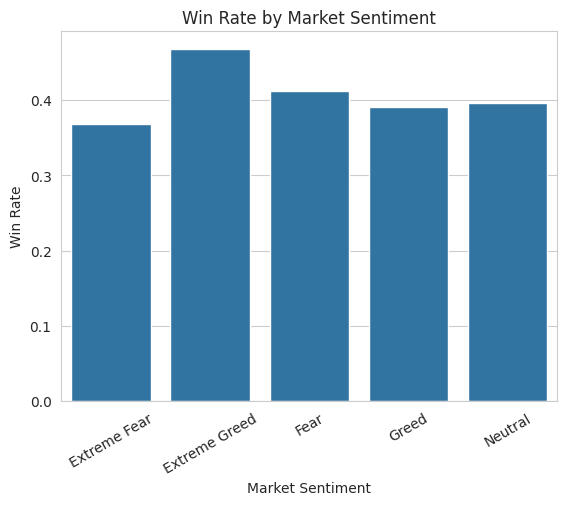

In [33]:
win_rate = df.groupby('classification')['is_profit'].mean().reset_index()

plt.figure()
sns.barplot(x='classification', y='is_profit', data=win_rate)
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=30)
plt.show()

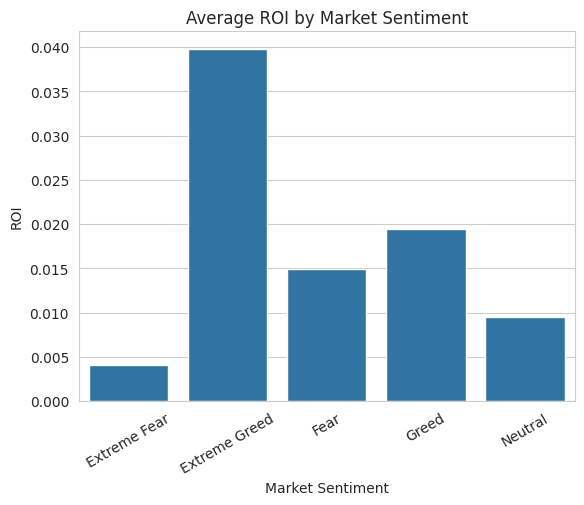

In [34]:
roi_data = df.groupby('classification')['roi'].mean().reset_index()

plt.figure()
sns.barplot(x='classification', y='roi', data=roi_data)
plt.title("Average ROI by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("ROI")
plt.xticks(rotation=30)
plt.show()

In [37]:
risk_analysis = df.groupby('classification').agg({
    'position_size': 'mean',
    'pnl': 'mean'
})

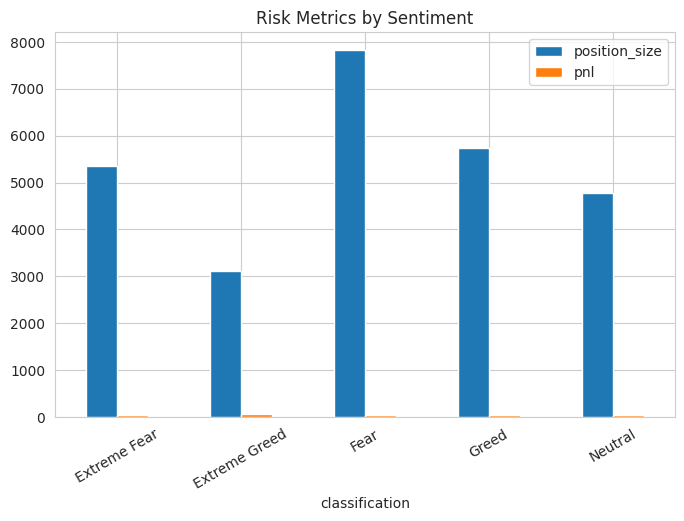

In [38]:
risk_analysis.plot(kind='bar', figsize=(8,5))
plt.title("Risk Metrics by Sentiment")
plt.xticks(rotation=30)
plt.show()

In [39]:
volatility = df.groupby('classification')['pnl'].std()

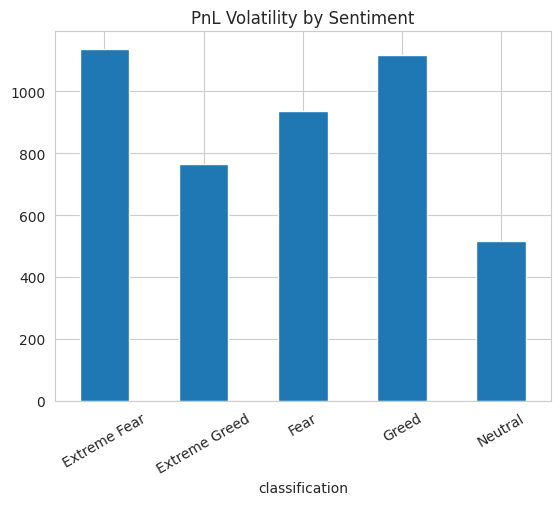

In [40]:
volatility.plot(kind='bar')
plt.title("PnL Volatility by Sentiment")
plt.xticks(rotation=30)
plt.show()

In [42]:
direction_bias = df.groupby(['classification', 'side']).size().unstack()

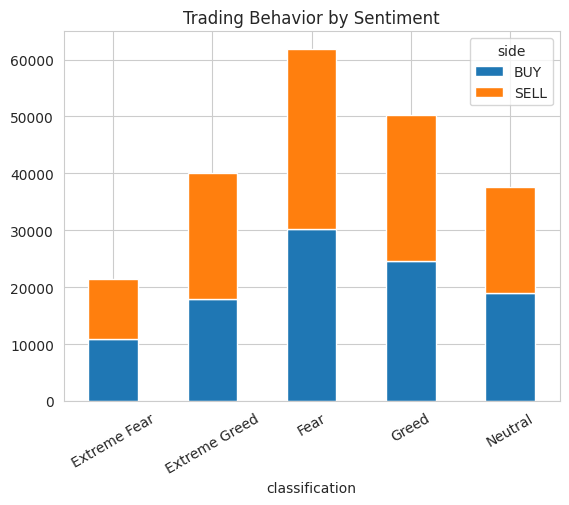

In [43]:
direction_bias.plot(kind='bar', stacked=True)
plt.title("Trading Behavior by Sentiment")
plt.xticks(rotation=30)
plt.show()

In [44]:
trader_stats = df.groupby('account').agg({
    'pnl': 'sum',
    'is_profit': 'mean',
    'roi': 'mean',
    'position_size': 'mean'
}).reset_index()

trader_stats.columns = ['account', 'total_pnl', 'win_rate', 'avg_roi', 'avg_size']

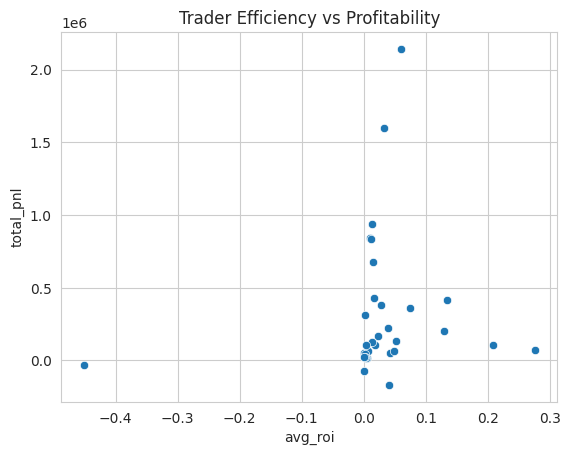

In [45]:
sns.scatterplot(data=trader_stats, x='avg_roi', y='total_pnl')
plt.title("Trader Efficiency vs Profitability")
plt.show()

In [46]:
trader_sentiment = df.pivot_table(
    index='account',
    columns='classification',
    values='pnl',
    aggfunc='mean'
).fillna(0)

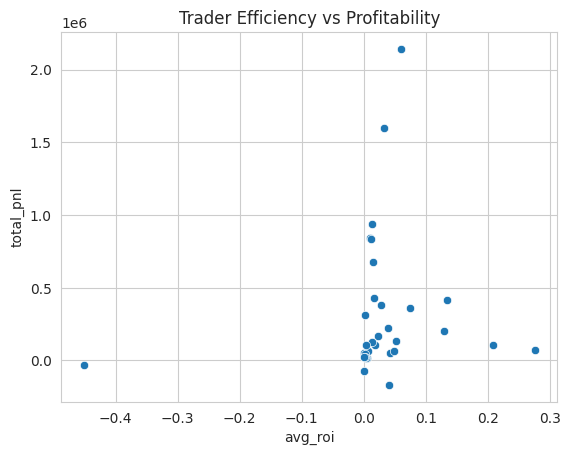

In [47]:
sns.scatterplot(data=trader_stats, x='avg_roi', y='total_pnl')
plt.title("Trader Efficiency vs Profitability")
plt.show()

In [48]:
top_traders = trader_stats.sort_values(by='total_pnl', ascending=False).head(10)

In [49]:
greed_strategy = df[df['classification'].str.contains('Greed')]
fear_strategy = df[df['classification'].str.contains('Fear')]

print("Greed Total PnL:", greed_strategy['pnl'].sum())
print("Fear Total PnL:", fear_strategy['pnl'].sum())

Greed Total PnL: 4865300.583624
Fear Total PnL: 4096265.690132


In [50]:
low_risk = df[df['position_size'] < df['position_size'].quantile(0.75)]

print("Low Risk Strategy PnL:", low_risk['pnl'].sum())

Low Risk Strategy PnL: 1624465.114079


In [51]:
top_accounts = top_traders['account']

copy_trading = df[df['account'].isin(top_accounts)]
print("Copy Trading PnL:", copy_trading['pnl'].sum())

Copy Trading PnL: 8623558.73782


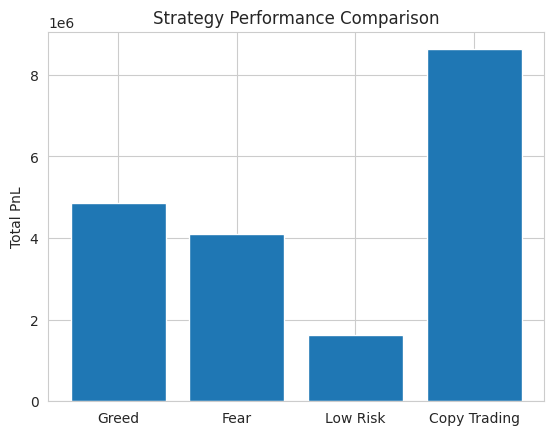

In [52]:
strategies = {
    "Greed": greed_strategy['pnl'].sum(),
    "Fear": fear_strategy['pnl'].sum(),
    "Low Risk": low_risk['pnl'].sum(),
    "Copy Trading": copy_trading['pnl'].sum()
}

plt.bar(strategies.keys(), strategies.values())
plt.title("Strategy Performance Comparison")
plt.ylabel("Total PnL")
plt.show()

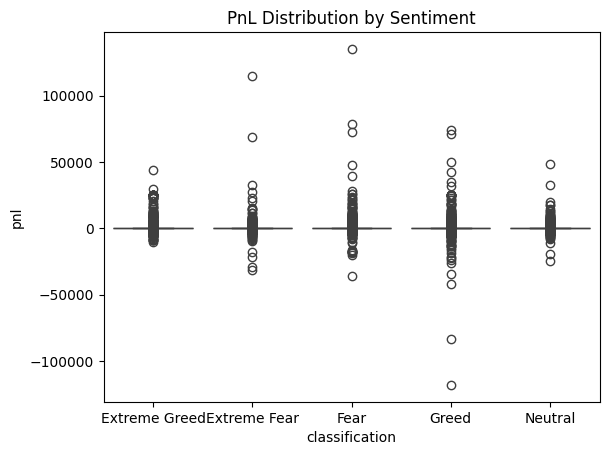

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='pnl', data=df)
plt.title("PnL Distribution by Sentiment")
plt.show()